### 데이터 토큰화
- 텍스트를 모델에 넣으려면 먼저 정수 시퀀스로 변환해야 함
#### 토큰화 방식 
- Subword 방식(BPE) - GPT계열

- BPE 작동 원리 : 자주 함계 나오는 문자 쌍을 반복적으로 합쳐서 어휘를 만듬

In [51]:
from collections import Counter, defaultdict
# defaultdict : 일반 딕셔너리는 없는 키에 접근하면 에러
# defaultdict(int)는 없는 키에 접근하면 자동으로 0을 넣어줌 => 빈도 카운팅에 적합
import re
from typing import List, Dict, Tuple
# 함수 인자와 반환값의 타입을 명시 => 코드 가독성과 IDE 자동완성을 위해
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

In [ ]:
corpus = [
    "hello world hello there",
    "hello beautiful world",
    ...
]

class BPETokenizer:
    def __init__(self):
        self.word_freqs = defaultdict(int)  
        # 각 단어가 corpus에서 몇 번 나왔는지 저장
        # {"hello": 4, "world": 3} 이런 식
        # 빈도가 높은 쌍을 먼저 병합하는 BPE 특성상 필수
        self.merges = {}
        # 병합 규칙을 저장 {('h','e'): 'he'} 형태
        # 나중에 새로운 단어를 토큰화할 때 이 규칙을 적용
        self.vocab = set()
        self.merge_history = []
        # 병합 과정을 단계별로 기록

    def _build_initial_vocab(self,corpus: List[str]):
        for text in corpus:
            words = text.split()    # 문장을 공백 기준으로 단어로 쪼갬
            for word in words:
                self.word_freqs[word] += 1
                # 단어 등장 횟수 카운팅
                # defaultdict라서 처음 나온 단어도 에러 없이 0에서 1됨
        
        for word in self.word_freqs:
            for char in word:   # 단어를 문자 단위로 쪼개서 초기 어휘를 만듬
                self.vocab.add(char)
        self.vocab.add('</w>')  # 단어 끝을 표시하는 특수 토큰, 단어의 경계를 모델이 알 수 있게
        return self

    def get_stats(self, vocab: Dict[str, int]) -> Dict[Tuple[str, str], int]:
        pairs = defaultdict(int)
        for word, freq in vocab.items():    # 현재 어휘 사전에서 단어와 빈도를 함께 꺼냄
            symbols = word.split()      
            # 현재 단어 표현을 토큰 단위로 쪼갬
            # "h e ll o </w>" → ['h', 'e', 'll', 'o', '</w>']
            for i in range(len(symbols) - 1):
                pairs[symbols[i], symbols[i+1]] += freq
                # 인접한 두 토큰의 쌍을 만들고 빈도 누적
                # 단어 자체의 빈도 곱해야 합 => += freq
                # "hello"가 4번 나왔으면 그 안의 쌍도 4번씩 카운팅
        return pairs

    def merge_vocab(self, pair: Tuple[str, str], vocab: Dict[str, int]) -> Dict[str, int]:
        new_vocab = {}
        bigram = ' '.join(pair)     # 병합할 쌍을 공백으로 연결 : ('h', 'e') → 'h e'
        replacement = ''.join(pair) # 병합 결과 : ('h', 'e') → 'he' 공백 없이 합침
        for word in vocab:
            new_word = word.replace(bigram, replacement) 
            # 어휘 사전의 모든 단어에서 해당 쌍을 찾아 병합된 토큰으로 교체
            new_vocab[new_word] = vocab[word]
            # 단어 자체의 빈도는 그대로 유지
            # 병합이 일어나도 단어 등장 횟수는 변하지 않음
        return new_vocab

    def train(self, corpus: List[str], num_merges: int = 10):
        self._build_initial_vocab(corpus)

        vocab = {}
        for word, freq in self.word_freqs.items():
            vocab[' '.join(word) + ' </w>'] = freq
        
        for i in range(num_merges):
            pairs = self.get_stats(vocab)

            if not pairs:
                break

            best_pair = max(pairs, key=pairs.get)
            best_freq = pairs[best_pair]
            vocab = self.merge_vocab(best_pair, vocab)
            self.merges[best_pair] = ''.join(best_pair)
            new_token = ''.join(best_pair)
            self.vocab.add(new_token)
    
def tokenize_word(word: str, merges: dict, vocab: set) -> List[str]:
    chars = list(word) + ['</w>']

    for pair, new_token in merges.items():
        while True:
            found = False
            for j in range(len(chars) - 1):
                if chars[j] == pair[0] and chars[j+1] == pair[1]:
                    chars[j:j+2] = [new_token]
                    found = True
                    break
            if not found:
                break
    return chars

### CLM(Causal Language Modeling) - GPT계열의 학습 방식
- 이전 토큰들을 보고 다음 토큰을 예측
- 정답 레이블을 따로 만들 필요 없이 텍스트 자체가 학습 데이터가 됨 (자기감독학습)

#### 손실 함수 Cross Entropy Loss
- 모델이 정답 토큰에 얼마나 높을 확률을 줬는지 측정
- 확률이 낮을수록 손실이 커지고, 그 신호로 가중치를 업데이트


In [62]:
import numpy as np
import matplotlib.pyplot as plt

corpus = "hello world today is a good day to learn"
chars = sorted(set(corpus))
char2idx = {c: i for i, c in enumerate(chars)}  
# 문자 -> 숫자로 변환하는 딕셔너리
# 숫자 -> 문자 변환, 모델 출력을 다시 텍스트로 바꿀 때
idx2char = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars) # 어휘 사전 크기

In [63]:
tokens = [char2idx[c] for c in corpus]
# corpus의 모든 무자를 숫자로 변환한 리스트

block_size = 8
# 모델이 한 번에 볼 수 있는 토큰 수. 8개를 보고 9번째를 예측
X, Y = [], []
for i in range(len(tokens) - block_size):   #
    # 8칸 짜리 창문을 한 칸씩 밀면서 (X,Y) 쌍을 만듬
    X.append(tokens[i:i+block_size])
    Y.append(tokens[i+block_size])

X = np.array(X)
Y = np.array(Y)

In [64]:
# softmax & Cross Entropy 구현
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    # np.exp(x): 각 값을 e의 거듭제곱으로 변환, 로짓(raw 점수)을 양수로 만듬
    # - np.max() : 각 행의 최댓값을 빼줌, 큰 숫자를 그대로 exp하면 값이 overflow
    return e_x / e_x.sum(axis=1, keepdims=True)
    # keepdims=True : 나누기 할 때 shape이 맞도록 차원 유지 / 없으면 브로드캐스팅 오류

In [65]:
def cross_entropy_loss(logits, targets):
    probs = softmax(logits)     # 모델의 raw출력(로짓)을 확률로 변환
    N = len(targets)            # 배치 크기. 한 번에 몇 개의 샘플을 처리하는지
    correct_probs = probs[np.arange(N), targets]    
    # 전체 확률 중 정답 토큰에 해당하는 확률만 뽑음
    loss = -np.mean(np.log(correct_probs + 1e-8))   # + 1e-8 log0 막는 안전장치
    # 정답 확률에 log를 취하고 음수를 붙음. 
    # 확률이 1에 가까울 수록 log값은 0에 가까워지면서 log값이 매우 커짐 
    # -> 틀릭수록 손실이 크게 패널티
    return loss, probs

In [72]:
embedding_dim = 8
# 각 토큰을 몇 차원 벡터로 표현할지 
# 'a' 라는 문자 하나가 8개의 숫자로 이루어진 벡터가 됨

W_embed = np.random.randn(vocab_size, embedding_dim) * 0.01
# 임베딩 테이블 : 각각의 토큰에 대해 8차원 벡터가 저장되어 있음
# 학습하면서 의미 있는 벡터로 업데이트
W_out = np.random.randn(block_size * embedding_dim, vocab_size) * 0.01
# 출력 레이어 가중치 : 입력으로 64차원을 받아서 vocab_size개의 점수로 변환
b_out = np.zeros(vocab_size)
# 편향(bias) : 가중치 외에 더해주는 상수값, 모델 표현력을 높여줌

learning_rate = 0.01 
# 가중치를 한 번에 얼마나 업데이트 할지
epochs = 500
losses = []
# 학습하면서 손실 값을 저장해둘 리스트

In [73]:
for epoch in range(epochs):
    for i in range(len(X)):
        # 순전파
        x_sample = X[i]     # i번째 샘플 하나(8개의 토큰 인덱스로 이뤄진 배열)
        embed = W_embed[x_sample]   
        # 임베딩 테이블에서 각 토큰에 해당하는 벡터 가져옴
        # 8개 토큰 -> 각각 8차원 벡터 -> (8,8)shape
        embed_flat = embed.flatten()
        # (8,8)행렬을 -> (64,) 1차원으로 펼침 
        # 선형 레이어에 넣으려면 1차원이어야 함 
        logits = embed_flat @ W_out + b_out
        # 선형 변환. 64차원 입력을 15차원 출력(각 토큰의 점수)으로 변환
        logits = logits.reshape(1, -1)
        # cross_entropy_loss 함수가 2차원 입력을 기대하기 때문에
        target = np.array([Y[i]])
        loss, probs = cross_entropy_loss(logits, target)
        losses.append(loss)
    
        # 역전파 (그래디언트 계산)
        dlogits = probs.copy()      # 역전파 시작점
        dlogits[0, target[0]] -= 1  # 정답 위치의 그래디언트만 1을 뺌
        # Cross Entropy + Softmax 미분의 결과가 "에측확률-정답(0또는1)"

        dW_out = embed_flat.reshape(-1, 1) @ dlogits
        # 출력 가중치의 그래디언트, 입력과 출력 그래디언트의 외적으로 계산
        db_out = dlogits.squeeze()
        # 편향의 그래디언트는 dlogits 그 자체
        dembed_flat = dlogits @ W_out.T
        # 임베딩 레이어까지 그래디언트를 전달
        # W_out.T로 역방향으로 흘려보냄
        dembed = dembed_flat.reshape(block_size, embedding_dim)

        # 가중치 업데이트
        W_out -= learning_rate * dW_out
        # 실제 가중치 업데이트
        b_out -= learning_rate * db_out
        for j, idx in enumerate(x_sample):
            W_embed[idx] -= learning_rate * dembed[j]
            # 샘플에서 사용된 토큰의 임베딩 벡터만 업데이트, 사용 안 된 토큰은 안건드림


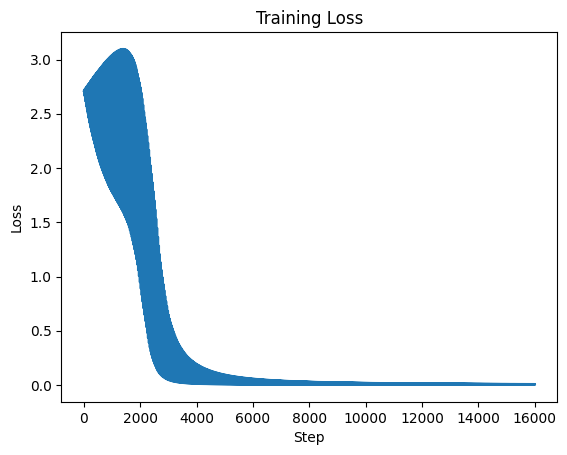

In [74]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

### Scaling Laws - LLM의 황금률
#### Scaling Law
0 모델 성능(손실 L)이 모델 파라미터 수 N, 훈련 토큰 수 D, 계산량 C에 따라 어떻게 변하는지 설명하는 '경험적 관계식'
- 같은 예산으로 모델 크기와 데이터 양을 어떻게 나눠야 가장 효휼적인가

#### Kaplan (OpenAI,2020)
- 주장 : 모델 크기가 중요
- 최적 비율 : N = D
- GPT-3 평가 : 잘 설계됨

#### Chinchilla (DeepMind,2022)
- 주장 : 모델과 데이터 균형이 중요
- 최적 비율 : D ≈ 20N
- GPT-3 평가 : 데이터 부족(D/N=1.7배)

In [ ]:
# Kaplan Scalling Law class

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class KaplanScalingLaw: 
    def __init__(self):
        self.alpha = 0.07   
        # 모델 크기 N이 손실에 영향을 주는 지수
        # 값이 작다는 건 N을 10배 키워도 손실이 조금밖에 안 줄어든다
        self.beta = 0.16
        # 데이터 D가 손실에 영향을 주는 지수
        # alpha보다 크기 때문에 데이터가 모델 크기보다 손실 감소에 더 효과적
        self.a = 0.5
        self.b = 0.5
        self.c = 0.5
    
    def compute_loss(self, N, D):
        return self.a * (N ** (-self.alpha)) + self.b * (D ** (-self.beta)) + self.c

    # Kaplan 손실 공식 : L = a * N^(-alpha) + b * D^(-beta) + c
    # N ** (-self.alpha) : N이 커질수록 이 값은 작아짐
    # 모델이 클수록 손실이 줄어듬
    
    # D ** (-self.beta) : D가 커질수록 이 값도 작아짐
    # 데이터가 많을수록 손실이 줄어듬

    # + self.c : 아무리 모델을 키우고 데이터를 늘려도 줄일 수 없는 최소 손실 => 언어 자체의 불확실성

    def optimal_allocation(self, compute_budget):
        optimal_N = np.sqrt(compute_budget / 6.0)
        optimal_D = np.sqrt(compute_budget / 6.0)
        return optimal_N, optimal_D
    
    # compute_budget : 총 계산 예산 C => C ≈ 6 * N * D 공식
    # / 6.0 : 계산량 근사식 C = 6ND 에서 6을 나눠주는 것
    # forward/ backward pass를 합친 경험적 계수

    # np.sqrt(C / 6) : Kaplan은 N = D로 놓고 최적화
    # C = 6 * N * N => n = sqrt(C/6)



In [15]:
# Chinchilla & 비교 분석

class ChinchillaScalingLaw:
    def __init__(self):
        self.alpha = 0.07
        self.beta = 0.16
        self.A = 0.5
        self.B = 0.5
        self.E = 0.5
    # 계수 alpha, beta는 Kaplan과 동일, 하지만 해석과 최적 배분 전략이 다름
    # E(Entropy) = 0.5 : Kaplan의 c와 같은 역할 (최소손실)

    def compute_loss(self, N, D):
        return self.E + self.A / (N ** self.alpha) + self.B / (D** self.beta)
    # Chinchilla 손실 공식 : L = E + A/N^alpha + B/D^beta
    # Kaplan : a * N^(-alpha) -> 곱셈형태
    # Chinchilla : A / N^alpha -> 나눗셈 형태
    # 수학적으로 동일, Chinchilla는 "N이 커질수록 이항이 0에 가까워진다"는 걸 더 직관적으로 표현

    def optimal_allocation(self, compute_budget):
        optimal_N = np.sqrt(compute_budget / 120.0)
        optimal_D = 20.0 * optimal_N
        return optimal_N, optimal_D
    # / 120.0 : C = 6 * N * D에 D =20N을 대입하면 C = 120 * n^2
    # => N = sqrt(c / 120)

    # 20.0 * optimal_N : Chinchilla의 핵심 결론
    # 파라미터 1개당 토큰 20개가 최전
    # => 모델을 작게 하고 데이터를 훨씬 많이 쓰는 전략

In [84]:
budget_scenarios = [
    ("소규모",  1e15),
    ("중규모",  1e17),
    ("대규모",  1e19),
    ("초대규모", 1e21),
]

results = []
kaplan = KaplanScalingLaw()
chinchilla = ChinchillaScalingLaw()

for scenario_name, compute_budget in budget_scenarios:
    n_kaplan, d_kaplan = kaplan.optimal_allocation(compute_budget)
    loss_kaplan = kaplan.compute_loss(n_kaplan, d_kaplan)

    n_chinchilla, d_chinchilla = chinchilla.optimal_allocation(compute_budget)
    loss_chinchilla = chinchilla.compute_loss(n_chinchilla, d_chinchilla)

    results.append({
        '시나리오' : scenario_name,
        'Kaplan_model' : f"{n_kaplan:.2e}",
        'Kaplan_data' : f"{d_kaplan:.2e}",
        'Kaplan_loss' : f"{loss_kaplan:.4f}",
        'Chinchilla_model': f"{n_chinchilla:.2e}",
        'Chinchilla_data' : f"{d_chinchilla:.2f}",
        'Chinchilla_loss' : f"{loss_chinchilla:.4f}",
        '성능차': f"{((loss_kaplan - loss_chinchilla) / loss_kaplan * 100):.1f}%"
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
# 성능차 : (Kaplan 손실 - Chinchilla 손실) / Kaplan 손실 * 100 이에요. Chinchilla가 항상 손실이 낮게 나옴
# 같은 예산에서 더 효율적

시나리오 Kaplan_model Kaplan_data Kaplan_loss Chinchilla_model Chinchilla_data Chinchilla_loss   성능차
 소규모     1.29e+07    1.29e+07      0.6953         2.89e+06     57735026.92          0.7051 -1.4%
 중규모     1.29e+08    1.29e+08      0.6605         2.89e+07    577350269.19          0.6700 -1.5%
 대규모     1.29e+09    1.29e+09      0.6326         2.89e+08   5773502691.90          0.6416 -1.4%
초대규모     1.29e+10    1.29e+10      0.6101         2.89e+09  57735026918.96          0.6183 -1.4%


In [25]:
actual_models = pd.DataFrame([
    {'이름': 'GPT-2',      '파라미터': 1.5e9,   '훈련토큰': 4.0e10,  '연도': 2019},
    {'이름': 'GPT-3',      '파라미터': 1.75e11, '훈련토큰': 3.0e11,  '연도': 2020},
    {'이름': 'Chinchilla', '파라미터': 7.0e10,  '훈련토큰': 1.4e12,  '연도': 2022},
    {'이름': 'LLaMA-7B',   '파라미터': 7.0e9,   '훈련토큰': 1.0e12,  '연도': 2023},
    {'이름': 'LLaMA-65B',  '파라미터': 6.5e10,  '훈련토큰': 1.4e12,  '연도': 2023},
])

actual_models['D/N 비율'] = actual_models['훈련토큰'] / actual_models['파라미터']
actual_models['계산량'] = 6 * actual_models['파라미터'] * actual_models['훈련토큰']

actual_models

,이름,파라미터,훈련토큰,연도,D/N 비율,계산량
0,GPT-2,1.500000e+09,4.000000e+10,2019,26.666667,3.600000e+20
1,GPT-3,1.750000e+11,3.000000e+11,2020,1.714286,3.150000e+23
2,Chinchilla,7.000000e+10,1.400000e+12,2022,20.000000,5.880000e+23
3,LLaMA-7B,7.000000e+09,1.000000e+12,2023,142.857143,4.200000e+22
4,LLaMA-65B,6.500000e+10,1.400000e+12,2023,21.538462,5.460000e+23


### In-context Learning (ICL)
#### ICL
- 모델 가중치를 업데이트 하지 않고, 프롬프타 안에 예시를 넣는 것만으로 모델이 태스크를 수행
- Fine-tuning 없이 동작

#### 3가지 방식
- zero-shot
    - 예시 수 : 0개
    - 장점 : 빠름, 프롬프트 짧음
    - 단점 : 정확도 낮을 수 있음
- One-shot
    - 예시 수 : 1개
    - 장점 : 패턴 힌트 제공
    - 단점 : 예시 품질에 크게 의존
- Few-shot
    - 예시 수 : 3~5개
    - 장점 : 높은 성능
    - 단점 : 프롬프트 길어짐

In [26]:
import os
from dotenv import load_dotenv
from openai import OpenAI

openai_client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])
openai_model = 'gpt-4o'

# OpenAI(api_key=...) : OpenAI클라이언트 객체를 만듬
# 이후 모든 API 호출은 이 객체를 통해서 함

# openai_model = 'gpt-4o' : 어떤 모델을 쓸지 지정

In [30]:
def call_openai_sentiment(prompt, max_output_tokens=30):
    response = openai_client.responses.create(
        model=openai_model,
        instructions=(
            '너는 영화 리뷰 감성을 분류하는 분류기야'
            '반드시 긍정 부정 중립 중 하나의 한국어 라벨만 출력해'  # 출력 형식 강제, 길게 답하는거 방지
            '설명 번호 영어 번역은 출력하지마'
        ),
        input=prompt,   # 실제 분류할 리뷰 텍스트, 호출할 때마다 달라지는 부분
        max_output_tokens=max_output_tokens
    )
    return response.output_text.strip()
# instructions : 모델에게 주는 시스템 지시문 
# 이 지시문은 모든 호출에서 동일하게 적용

# max_output_tokens=30 : 출력 토큰을 30개로 제한 => 비용 절감 효과
# .strip() : API응답에 불필요한 공백이 붙어오는 경우 방지


In [28]:
zero_shot_prompt = """
다음 영화 리뷰의 감성을 분석하세요

리뷰: '이 영화는 정말 멋있었어!'
감성:
"""
# 예시가 0개 => 바로 분류해 달라고 요청
# 감성: 뒤를 비워두는게 핵심 => 모델이 빈칸을 채우는 방식으로 동작
# 빈칸 채우기처럼 다음에 올 텍스트를 예측
# 장점 : 프롬프트가 짧아서 토큰 비용 절감

one_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요.

리뷰: "영화가 정말 재미있었어요!"
감성: 긍정

리뷰: "이 영화는 정말 멋있었어!"
감성:
'''
# 예시가 1개 => 정답 예시를 보여주고 같은 형식으로 답하도록 유도
# 리뷰 -> 감성 패턴을 한 번 보여줬기 때문에 모델이 출력 형식을 파악
# 단점 : 예시가 1개 뿐이라 "긍정" 예시만 봤음. "부정"이나 "중립"이 뭔지는 아직 모르는 상태

few_shot_prompt = '''
다음 영화 리뷰의 감성을 분석하세요.

리뷰: "영화가 정말 재미있었어요!"
감성: 긍정

리뷰: "완전히 실망했어요."
감성: 부정

리뷰: "그런대로 괜찮네요."
감성: 중립

리뷰: "이 영화는 정말 멋있었어!"
감성:
'''
# 예시가 3개 => 긍정/부정/중립 세가지 케이스를 모두 보여줌
# 모델이 세 가지 레이블이 있다는 걸 알게 되고, 각각 어떤 문장이 해당되는지 패턴을 파악
# one-shot보다 안정적으로 원하는 형식의 답이 나옴

In [31]:
openai_results = {
    'zero-shot': call_openai_sentiment(zero_shot_prompt),
    'one-shot': call_openai_sentiment(one_shot_prompt),
    'few-shot': call_openai_sentiment(few_shot_prompt),
}
openai_results

# 이 예시에선 모두 정답을 맞히지만, 모호한 문장이나 복잡한 태스트에서는
# few-shot이 압도적으로 유리

{'zero-shot': '긍정', 'one-shot': '긍정', 'few-shot': '긍정'}

### 프롬프트 최적화 전략
- 같은 모델이라도 프롬프트를 어떻게 쓰느냐에 따라 결과가 완전히 달라짐
- Fine-tuning없이 성능을 끌어올릴 수 있는 가장 빠른 방법

### 핵심 전략 3가지
- 역할 부여
    - "너는 ~ 전문가야" => 답변 스타일과 깊이가 달라짐
- Chain of Thought
    - "단계적으로 생각해" => 복잡한 추론 성능 향상
- 출력 형식 지정
    - JSON/표 형태로 요청 => 파싱 가능한 구조화된 출력

In [33]:
# 프롬프트 최적화
import os
from openai import OpenAI

client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

def get_completion(prompt, system_prompt=None, max_tokens=500):
    # system_prompt = None : 시스템 프롬프트가 없어도 함수가 동작하게
    messages = [{"role": "user", "content": prompt}]
    # OpenAI aPI는 대화를 메세지 리스트로 받음
    # role => user : 사용자 발화, system : 지시문, assistant : 모델 발화

    if system_prompt:
        messages.insert(0, {"role": "system", "content": system_prompt})
        # messages.insert(0,...) : 시스템 프롬프트가 있으면 리스트 맨 앞에 삽입
        # 시스템 메세지는 항상 대화의 첫번째로 와야 함
    response = client.chat.completions.create(
        # Chat 형식의 API를 호출 
        # responcse.create와 다른 엔드 포인트
        model="gpt-4o",
        messages=messages,
        max_tokens=max_tokens
    )
    return response.choices[0].message.content
    # API응답에서 실제 텍스트만 추출
    # choices[0] : API가 여러 개의 응답을 동시에 생성할 수도 있기 때문에 1개만 받기

In [34]:
# 역할 부여 & chain of Thought

# 역할 부여 없이
basic_prompt = "파이썬에서 메모리 누수가 발생하는 이유를 설명해줘"
basic_response = get_completion(basic_prompt)

# 역할 부여
expert_system = "당신은 10년 경력의 파이썬 시니어 엔지니어입니다. 기술적으로 정확하고 실무 중심으로 답변하세요."
expert_response = get_completion(basic_prompt, system_prompt=expert_system)

# 질문 자체는 동일, 시스템 프롬프트 달라짐
# 역할 부여가 없으면 모델은 일반적인 수준으로 답함, 누구한테 말하는지 모르니까 중간 수준으로 맞춤
# 역할 부여는 system_prompt에 대화전체에 일관되게 적용되게

In [ ]:
# chain of Thought 없이
direct_prompt = """
다음 문제를 풀어라.
철수는 사과 5개를 가지고 있었다. 영희에게 2개를 주고, 마트에서 3개를 샀다. 
지금 철수가 가진 사과는?
"""

# chain of Thought 적용
cot_prompt = """
다음 문제를 풀어라. 단계적으로 생각하고 풀이 과정을 보여줘.
철수는 사과 5개를 가지고 있었다. 영희에게 2개를 주고, 마트에서 3개를 샀다.
지금 철수가 가진 사과는?
""" 
direct_response = get_completion(direct_prompt)
cot_response = get_completion(cot_prompt)

# "단계적으로 생각하고 풀이 과정을 보여줘" 한 문장이 핵심이에요. 이게 Chain of Thought(CoT) 트리거

In [42]:
# 출력 형식 지정 & 전략 비교

# 형식 지정 없이
unformatted_prompt = "파이썬 리스트, 딕셔너리, 튜플을 비교해줘"

# JSON. 형식 지정
json_prompt = """
파이썬 리스트, 딕셔너리, 튜플을 비교해줘.
반드시 아래 JSON 형식으로만 답해줘. 다른 설명은 하지마.

{
  "자료구조명": {
    "특징": "...",
    "수정가능": true/false,
    "사용예시": "..."
  }
}
"""

unformatted_response = get_completion(unformatted_prompt)
json_response = get_completion(json_prompt)

In [ ]:
import json

def parse_json_response(response_text):
    try:
        # 마크다운 코드블록 제거
        cleaned = response_text.replace('```json', '').replace('```', '').strip()
        # 모델이 JSON을 마크다운 코드블록으로 감싸서 줄 때가 많음 ```json 이런식`
        return json.loads(cleaned)
    except json.JSONDecodeError as e:   # JSON형식이 잘못됐을 때 발생하는 에러
        print(f"JSON 파싱 실패: {e}")
        return None

parsed = parse_json_response(json_response)

In [49]:
strategies = {
    "기본 프롬프트": {
        "prompt": "파이썬 딕셔너리란?",
        "system": None
    },
    "역할 부여": {
        "prompt": "파이썬 딕셔너리란?",
        "system": "당신은 파이썬 전문 강사입니다. 초보자가 이해하기 쉽게 설명하세요."
    },
    "CoT 적용": {
        "prompt": "파이썬 딕셔너리란? 단계적으로 핵심 개념부터 설명해줘.",
        "system": None
    },
    "형식 지정": {
        "prompt": "파이썬 딕셔너리를 설명해줘. 정의/특징/예시 순서로 답해줘.",
        "system": None
    },
    "전략 결합": {
        "prompt": "파이썬 딕셔너리를 단계적으로 설명해줘. 정의/특징/예시 순서로 답해줘.",
        "system": "당신은 파이썬 전문 강사입니다. 초보자가 이해하기 쉽게 설명하세요."
    }
}

results = {}
for strategy_name, config in strategies.items():
    results[strategy_name] = get_completion(
        config['prompt'],
        system_prompt=config['system']
    )

In [50]:
for strategy_name, response in results.items():
    print(f"\n{'='*50}")
    print(f"전략: {strategy_name}")
    print(f"{'='*50}")
    print(response[:200])  # 앞 200자만 출력


전략: 기본 프롬프트
파이썬에서 딕셔너리는 변경 가능한(Mutable) 데이터 타입 중 하나로, 키-값 쌍(key-value pair)으로 이루어져 있습니다. 딕셔너리는 데이터를 연관 관계로 저장하고 싶을 때 사용합니다. 각 키는 유일해야 하며, 변경 불가능한(Immutable) 타입이어야 하지만, 값은 다양한 타입의 데이터가 될 수 있습니다.

딕셔너리는 중괄호 `{}`를 사

전략: 역할 부여
파이썬에서 딕셔너리는 데이터의 짝(pair)을 저장할 수 있는 매우 유용한 자료형입니다. 딕셔너리는 `키(key)`와 `값(value)`의 쌍으로 이루어져 있으며, 키는 고유해야 하기 때문에 중복될 수 없습니다. 즉, 각 키는 하나의 값을 가리킵니다.

딕셔너리를 이해할 때, 현실 세계의 예로 전화번호부를 생각할 수 있습니다. 전화번호부에서는 사람의 이름(

전략: CoT 적용
파이썬 딕셔너리(Dictionary)는 파이썬의 내장 데이터 타입 중 하나로, 키(key)와 값(value)의 쌍으로 데이터를 저장하는 자료 구조입니다. 딕셔너리는 연관 배열(associative array) 혹은 해시 테이블(hash table)이라고도 불리며, 고유한 키를 사용해 값을 효율적으로 검색할 수 있습니다. 딕셔너리의 핵심 개념을 단계별로 설명

전략: 형식 지정
정의:
파이썬의 딕셔너리(Dictionary)는 키-값(key-value) 쌍을 저장하는 자료형입니다. 이는 연관 배열(associative array)이라고도 하며, 키를 사용하여 값을 빠르게 조회할 수 있는 자료 구조입니다.

특징:
1. **키-값 쌍**: 딕셔너리는 각 요소가 키-값 쌍으로 이루어져 있습니다. 키는 고유해야 하며, 불변(immutab

전략: 전략 결합
물론이죠! 파이썬 딕셔너리에 대해 단계적으로 설명해드릴게요.

### 1. 정의
파이썬에서 딕셔너리는 데이터를 저장하기 위한 하나의 자료형입니다. 딕셔너리는 키(key)와 값(value) 쌍을 저장하는데, 마치 실제 사전에서 단어(키)와 그 뜻(값

In [80]:
# 데이터 & PromptOpimizer class

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
# permutations : 예시 순서의 모든 조합을 만들 때 사용 
# 어떤 순서가 가장 성능이 좋은지 실험할 때 유용

legal_data = [
    {"text": "본 계약의 유효 기간은 2024년 1월 1일부터 2025년 12월 31일까지이다.", "category": "기간", "difficulty": "easy"},
    {"text": "계약 당사자가 본 계약의 어떤 조항을 위반할 경우 상대방은 즉시 계약을 해제할 수 있다.", "category": "위약금", "difficulty": "medium"},
    {"text": "갑은 본 서비스와 관련하여 발생한 모든 손해에 대해 책임을 지지 아니한다.", "category": "책임제한", "difficulty": "medium"},
    {"text": "본 계약에 명시되지 않은 사항에 대해서는 관계 법령을 준용한다.", "category": "준거법", "difficulty": "hard"},
    {"text": "이용자는 언제든지 7일 이전 통지로 본 계약을 해지할 수 있다.", "category": "해지", "difficulty": "easy"},
    {"text": "당사자 간의 분쟁이 발생할 경우 서울중앙지방법원을 관할 법원으로 한다.", "category": "관할법원", "difficulty": "hard"},
]

test_data = [
    {"text": "본 서비스는 2024년 1월부터 시작된다.", "category": "기간"},
    {"text": "계약 위반 시 연 10%의 위약금을 청구할 수 있다.", "category": "위약금"},
    {"text": "본사는 서비스 중단에 대해 책임지지 않는다.", "category": "책임제한"},
    {"text": "분쟁은 중재법에 따라 처리된다.", "category": "준거법"},
]
# difficulty 필드가 핵심 : 나중에 Easy -> Medium -> Hard 순서로 정렬할 때 사용

In [86]:
class PromptOptimizer:
    def __init__(self):
        self.category_map = {
            "기간": ["시간", "기간", "날짜", "년도", "일자"],
            "위약금": ["위약금", "손해배상", "페널티", "과태료", "위반"],
            "책임제한": ["책임", "담당", "책임제한", "면책", "책임지지"],
            "준거법": ["법령", "준거법", "법률", "규정", "법"],
            "해지": ["해지", "종료", "종료", "폐기", "중단"],
            "관할법원": ["법원", "중재", "소송", "분쟁", "관할"],
        }
        # 각 카테고리에 해당하는 키워드 목록, 실제 LLM없이도 키워드 매칭으로 빠르게 분류 가능
        # 프롬프트 최적화 효과를 빠르게 평가하기 위한 용도
        
    def classify_simple(self, text):
        text_lower = text.lower()   # 대소문자 구분 없이 키워드 찾으려고 통일
        scores = {}
        for category, keywords in self.category_map.items():
            score = sum(1 for kw in keywords if kw in text_lower)
            # 텍스트에 키워드가 몇개 포함됐는지 겜, 가장 많이 매칭된 카테고리를 정답으로 반환
            scores[category] = score
        if max(scores.values()) == 0:
            return "기타"
            # 아무것도 안 걸리면 '기타'를 반환, 예외처리
        return max(scores, key=scores.get)
    
optimizer = PromptOptimizer()

for item in test_data:
    pred = optimizer.classify_simple(item['text'])
    print(f"조항: {item['text'][:30]}...")
    print(f"예측: {pred} / 정답: {item['category']}")
    print()

조항: 본 서비스는 2024년 1월부터 시작된다....
예측: 기타 / 정답: 기간

조항: 계약 위반 시 연 10%의 위약금을 청구할 수 있다....
예측: 위약금 / 정답: 위약금

조항: 본사는 서비스 중단에 대해 책임지지 않는다....
예측: 책임제한 / 정답: 책임제한

조항: 분쟁은 중재법에 따라 처리된다....
예측: 관할법원 / 정답: 준거법



In [82]:
# create_prompt & 순서 효과 비교
# 이 부분 추가 이해 필요
def create_prompt(examples, order="original"):
    if order == "random":
        examples = list(examples)
        np.random.shuffle(examples)

    elif order == "difficulty":
        difficulty_order = {"easy": 0, "medium": 1, "hard": 2}
        examples = sorted(examples, key=lambda x: difficulty_order.get(x.get("difficulty", "easy"), 0))
    
    elif order == "balanced":
        by_category = {}
        for ex in examples:
            cat = ex["category"]
            if cat not in by_category:
                by_category[cat] = []
            by_category[cat].append(ex)

        examples = []
        max_len = max(len(v) for v in by_category.values())
        for i in range(max_len):
            for cat in by_category:
                if i < len(by_category[cat]):
                    examples.append(by_category[cat][i])

    prompt = """다음 법률 문서의 조항을 카테고리로 분류하세요.
                카테고리: 기간, 위약금, 책임제한, 준거법, 해지, 관할법원
                응답 형식: 카테고리명만 출력하세요.
            """
    for ex in examples:
        prompt += f"조항: {ex['text']}\n"
        prompt += f"카테고리: {ex['category']}\n\n"
    
    return prompt, examples

In [83]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# 1. 최적화 프롬프트 생성
def create_optimized_prompt(examples):
    prompt = """당신은 법률 문서 분석 전문가입니다.
다음 법률 조항의 카테고리를 정확히 분류하세요.

## 카테고리 정의
- 기간: 계약의 유효 기간, 시작/종료 날짜
- 위약금: 계약 위반 시 페널티, 손해배상
- 책임제한: 당사자의 책임 범위 제한, 면책 조항
- 준거법: 계약 분쟁 시 적용 법령, 법률 준용
- 해지: 계약 해지 조건, 해지 절차
- 관할법원: 분쟁 해결 절차, 소송 관할권

## 분류 예시
"""
    for ex in examples:
        prompt += f"조항: \"{ex['text']}\"\n"
        prompt += f"→ 카테고리: {ex['category']}\n\n"
    
    prompt += "## 분류할 조항\n"
    prompt += "조항: \"{text}\"\n"
    prompt += "→ 카테고리: "
    
    return prompt

# 2. optimized_prompt 생성
optimized_prompt = create_optimized_prompt(legal_data[:3])

# 3. categories & normalize_category 정의
categories = ['기간', '위약금', '책임제한', '준거법', '해지', '관할법원']

def normalize_category(text):
    for category in categories:
        if category in text:
            return category
    return text.strip()

# 4. 모델 로드
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
).to(device)

# 5. 분류 함수 정의
def classify_with_huggingface(clause):
    prompt = optimized_prompt.format(text=clause)
    messages = [
        {"role": "system", "content": "너는 법률 문서 조항을 정해진 카테고리 중 하나로만 분류하는 전문가야. 설명 없이 카테고리명만 출력해."},
        {"role": "user", "content": prompt}
    ]
    
    chat_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(chat_prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    raw_output = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    return normalize_category(raw_output), raw_output

# 6. 실행
for item in test_data:
    prediction, raw_output = classify_with_huggingface(item['text'])
    print(f"조항: {item['text'][:30]}...")
    print(f"예측: {prediction} / 정답: {item['category']}")
    print()

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 6744.45it/s]


조항: 본 서비스는 2024년 1월부터 시작된다....
예측: 기간 / 정답: 기간

조항: 계약 위반 시 연 10%의 위약금을 청구할 수 있다....
예측: 위약금 / 정답: 위약금

조항: 본사는 서비스 중단에 대해 책임지지 않는다....
예측: 해지 / 정답: 책임제한

조항: 분쟁은 중재법에 따라 처리된다....
예측: 해지 / 정답: 준거법

